# Проект: Обучение с учителем: качество модели

**Цели проекта:**

1) Изучить пользовательскую активность с помощью модели МО, определить вероятность снижения активности.
2) Рассмотреть отдельный сегмент пользователей и разработать стратегию для увеличения пользовательской активности

**План исследования:**

1) Загрузить и предобработать данные; 

2) Провести исследовательский анализ данных;

3) Объединить данные для дальнейшей работы с моделью МО

4) Выполнить корреляционный анализ данных - изучить корреляцию между целевым и входными признаками; проверить отсутствие мультиколлинеарности, при необходимости убрать лишние столбцы

5) С помощью пайплайнов найти лучшую модель, определить лучшие гиперпараметры и лучшие методы подготовки данных перед МО;

6) Выполнить сегментацию покупателей и разработать стратегию повышения пользовательской активности;

7) Сформулировать итоговый вывод 

В качестве исходных данных были переданы следующие датафреймы:
 - market_file.csv - таблица с данными о поведении покупателя на сайте, о коммуникациях с покупателем и его продуктовом поведении; 
 - market_money.csv - таблица с данными о выручке, которую получает магазин с покупателя;
 - market_time.csv - таблица с данными о времени (в минутах), которое покупатель провёл на сайте в течение периода;
 - money.csv - таблица с данными о среднемесячной прибыли продавца за последние 3 месяца: какую прибыль получает магазин от продаж каждому покупателю.

In [1]:
!pip install phik -q
!pip install -q shap==0.40.0
!pip install --upgrade scikit-learn  -q #numpy numba matplotlib scipy -q


In [2]:
import pandas as pd
import numpy as np
import phik
import shap
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import (train_test_split, 
                                     RandomizedSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (OneHotEncoder,
                                  OrdinalEncoder,
                                  StandardScaler,
                                  MinMaxScaler)
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

##  Загрузка данных

In [3]:
df_market = pd.read_csv('/datasets/market_file.csv')
df_market.info()
df_market.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


In [4]:
df_market_money = pd.read_csv('/datasets/market_money.csv')
df_market_money.info()
df_market_money.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   Период   3900 non-null   object 
 2   Выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB


,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


In [5]:
df_time = pd.read_csv('/datasets/market_time.csv')
df_time.info()
df_time.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   Период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB


,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13


In [6]:
df_money = pd.read_csv('/datasets/money.csv', sep=';', decimal=',')
df_money.info()
df_money.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   Прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


В результате первичного просмотра в данных можно заметить следующие проблемы:
- неявные дубликаты в категориальных признаках (пример: 'стандартт', 'предыдцщий_месяц')
- аномально низкое значение прибыли в таблице money (возможно, ошибка возникла при внесении данных)

Пропусков в данных нет. Данные не отличаются от описания.

## Предобработка данных

In [7]:
df_market.columns = ['id', 'Покупательская_активность', 'Тип_сервиса', 'Разрешить_сообщать',
       'Маркет_актив_6_мес', 'Маркет_актив_тек_мес', 'Длительность',
       'Акционные_покупки', 'Популярная_категория',
       'Средний_просмотр_категорий_за_визит',
       'Неоплаченные_продукты_штук_квартал', 'Ошибка_сервиса',
       'Страниц_за_визит']

In [8]:
# предобрабатываем категориальные признаки таблицы df_market
df_market['id'] = df_market['id'].astype('str')

print(f'Уникальные значения столбца покупательская активность: \
\n{df_market["Покупательская_активность"].unique()}')

df_market['Тип_сервиса'] = df_market['Тип_сервиса'].str.replace('стандартт', 'стандарт')
print(f'Уникальные значения столбца тип сервиса: \
\n{df_market["Тип_сервиса"].unique()}')

print(f'Уникальные значения столбца разрешить сообщать: \
\n{df_market["Разрешить_сообщать"].unique()}')

print(f'Уникальные значения столбца популярная категория: \
\n{df_market["Популярная_категория"].unique()}')

print(f'Проверяем уникальность значений столбца id: \
\n{df_market["id"].value_counts().sort_values(ascending=False)}')

Уникальные значения столбца покупательская активность: 
['Снизилась' 'Прежний уровень']
Уникальные значения столбца тип сервиса: 
['премиум' 'стандарт']
Уникальные значения столбца разрешить сообщать: 
['да' 'нет']
Уникальные значения столбца популярная категория: 
['Товары для детей' 'Домашний текстиль' 'Косметика и аксесуары'
 'Техника для красоты и здоровья' 'Кухонная посуда'
 'Мелкая бытовая техника и электроника']
Проверяем уникальность значений столбца id: 
216150    1
216319    1
215357    1
215477    1
215765    1
         ..
215747    1
215789    1
215432    1
216282    1
216207    1
Name: id, Length: 1300, dtype: int64


In [9]:
# предобрабатываем количественные признаки таблицы df_market
print(f'Статистика признака маркет_актив_6_мес: \n{df_market["Маркет_актив_6_мес"].describe()}')

print(f'Статистика признака маркет_актив_тек_мес: \n{df_market["Маркет_актив_тек_мес"].describe()}')

print(f'Статистика признака длительность: \n{df_market["Длительность"].describe()}')

print(f'Статистика признака акционные_покупки: \n{df_market["Акционные_покупки"].describe()}') 

print(f'Статистика признака средний_просмотр_категорий_за_визит:\
\n{df_market["Средний_просмотр_категорий_за_визит"].describe()}')

print(f'Статистика признака неоплаченные_продукты_штук_квартал:\
\n{df_market["Неоплаченные_продукты_штук_квартал"].describe()}')

print(f'Статистика признака ошибка_сервиса: \n{df_market["Ошибка_сервиса"].describe()}') 

print(f'Статистика признака страниц_за_визит: \n{df_market["Страниц_за_визит"].describe()}') 

f'Количество явных дубликатов в таблице df_money: \
{df_market.duplicated().sum()}'

Статистика признака маркет_актив_6_мес: 
count    1300.000000
mean        4.253769
std         1.014814
min         0.900000
25%         3.700000
50%         4.200000
75%         4.900000
max         6.600000
Name: Маркет_актив_6_мес, dtype: float64
Статистика признака маркет_актив_тек_мес: 
count    1300.000000
mean        4.011538
std         0.696868
min         3.000000
25%         4.000000
50%         4.000000
75%         4.000000
max         5.000000
Name: Маркет_актив_тек_мес, dtype: float64
Статистика признака длительность: 
count    1300.000000
mean      601.898462
std       249.856289
min       110.000000
25%       405.500000
50%       606.000000
75%       806.000000
max      1079.000000
Name: Длительность, dtype: float64
Статистика признака акционные_покупки: 
count    1300.000000
mean        0.319808
std         0.249843
min         0.000000
25%         0.170000
50%         0.240000
75%         0.300000
max         0.990000
Name: Акционные_покупки, dtype: float64
Статистика

'Количество явных дубликатов в таблице df_money: 0'

В таблице df_market были обнаружены и исправлены следующие проблемы:
- неявные дубликаты в столбце тип_сервиса: стандартт и стандарт

In [10]:
df_market_money['id'] = df_market_money['id'].astype('str')
print(f'Статистика признака выручка: \n{df_market_money["Выручка"].describe()}')

Статистика признака выручка: 
count      3900.000000
mean       5025.696051
std        1777.704104
min           0.000000
25%        4590.150000
50%        4957.500000
75%        5363.000000
max      106862.200000
Name: Выручка, dtype: float64


In [11]:
print(f'Уникальные значения столбца период: \n{df_market_money["Период"].value_counts()}')

print(f'Проверяем уникальность значений столбца id: \
\n {df_market_money["id"].value_counts().sort_values(ascending=False)}')

df_market_money_new = df_market_money.pivot(index='id', columns='Период', values='Выручка')
print(f'Количество пропусков в таблице df_market_money_new:\n {df_market_money_new.isna().sum()}')
df_market_money_new = df_market_money_new.reset_index()

# формируем столбец сумма покупок за 3 месяца для дальнейшей обработки значений прибыли
df_market_money_new['Сумма'] = df_market_money_new['предыдущий_месяц'] + \
df_market_money_new['препредыдущий_месяц'] + df_market_money_new['текущий_месяц']
df_market_money_new.sort_values(by='Сумма').head()

Уникальные значения столбца период: 
предыдущий_месяц       1300
текущий_месяц          1300
препредыдущий_месяц    1300
Name: Период, dtype: int64
Проверяем уникальность значений столбца id: 
 216150    3
216319    3
215357    3
215477    3
215765    3
         ..
215533    3
215789    3
215432    3
216282    3
216207    3
Name: id, Length: 1300, dtype: int64
Количество пропусков в таблице df_market_money_new:
 Период
предыдущий_месяц       0
препредыдущий_месяц    0
текущий_месяц          0
dtype: int64


Период,id,предыдущий_месяц,препредыдущий_месяц,текущий_месяц,Сумма
0,215348,0.0,0.0,3293.1,3293.1
11,215359,0.0,0.0,4735.0,4735.0
9,215357,0.0,0.0,5986.3,5986.3
216,215564,2890.0,4213.0,3334.6,10437.6
368,215716,3067.0,4165.0,3343.9,10575.9


In [12]:
print(f'Количество явных дубликатов в таблице df_market_money: \
{df_market_money.duplicated().sum()}')

Количество явных дубликатов в таблице df_market_money: 0


В таблице df_market_money проблем нет: в столбце выручки нет аномальных значений в столбце период нет неявных дубликатов (если я правильно поняла, то значение препредыдущий_месяц возможно и не является дубликатом).

Также был проверен столбец id, сортировка показала, что у каждого id три значения времени: сводная таблица df_market_money_new и анализ пропусков в этом таблице показал, что эти три значения за текущий, предыдущий и препредыдущий месяцы есть у каждого пользователя. Это означает, что явных дубликатов в столбце id нет.

In [13]:
df_time['id'] = df_time['id'].astype('str')
df_time.columns = ['id', 'Период', 'Минут']

df_time['Период'] = df_time['Период'].str.replace('предыдцщий_месяц', 'предыдущий_месяц')
print(f'Уникальные значения столбца период: \n{df_time["Период"].value_counts()}')

Уникальные значения столбца период: 
предыдущий_месяц    1300
текущий_месяц       1300
Name: Период, dtype: int64


In [14]:
print(f'Статистика признака минут: \n{df_time["Минут"].describe()}')

print(f'Проверяем уникальность значений столбца id: \
\n{df_time["id"].value_counts().sort_values(ascending=False)}')

df_time_new = df_time.pivot(index='id', columns='Период', values='Минут')
print(f'Количество пропусков в таблице df_time_new:\n {df_time_new.isna().sum()}')
df_time_new.head()

Статистика признака минут: 
count    2600.000000
mean       13.336154
std         4.080198
min         4.000000
25%        10.000000
50%        13.000000
75%        16.000000
max        23.000000
Name: Минут, dtype: float64
Проверяем уникальность значений столбца id: 
216150    2
216319    2
215357    2
215477    2
215765    2
         ..
215533    2
215789    2
215432    2
216282    2
216207    2
Name: id, Length: 1300, dtype: int64
Количество пропусков в таблице df_time_new:
 Период
предыдущий_месяц    0
текущий_месяц       0
dtype: int64


Период,предыдущий_месяц,текущий_месяц
id,,
215348,13,14
215349,12,10
215350,8,13
215351,11,13
215352,8,11


In [15]:
print(f'Количество явных дубликатов в таблице df_time: {df_time.duplicated().sum()}')

Количество явных дубликатов в таблице df_time: 0


В столбце df_time были изменены названия столбцов (для того, чтобы они все были одинакового оформления). Неявных дубликатов в столбце "Период" нет, но была исправлена опечатка ("предыдцщий_месяц" на "предыдущий_месяц"), каких-либо аномальных значений в столбце "Минут" нет - минимальное значение - 4 минуты, максимальное - 23 минут, среднее и медианное значения составляют примерно 13 минут.

Также был проверен столбец id, сортировка показала, что у каждого id два значения времени: сводная таблица df_time_new и анализ пропусков в этом таблице показал, что эти два значения за текущий и предыдущий месяц у каждого пользователя. Это означает, что явных дубликатов в столбце id нет.

In [16]:
df_money['id'] = df_money['id'].astype('str')

df_money['Прибыль'] = df_money['Прибыль'] * 1000
print(f'Статистика признака прибыль: \n{df_money["Прибыль"].describe()}')

print(f'Проверяем уникальность значений столбца id: \
\n{df_money["id"].value_counts().sort_values(ascending=False)}')


Статистика признака прибыль: 
count    1300.000000
mean     3996.630769
std      1013.722112
min       860.000000
25%      3300.000000
50%      4045.000000
75%      4670.000000
max      7430.000000
Name: Прибыль, dtype: float64
Проверяем уникальность значений столбца id: 
216150    1
216319    1
215357    1
215477    1
215765    1
         ..
215747    1
215789    1
215432    1
216282    1
216207    1
Name: id, Length: 1300, dtype: int64


In [17]:
print(f'Количество явных дубликатов в таблице df_money: {df_money.duplicated().sum()}')

Количество явных дубликатов в таблице df_money: 0


В таблице df_money встретились аномальные значения прибыли, скорее всего все значения подразумевались в тыс. руб. судя по суммарной прибыли со столбца "Сумма" таблицы df_market_money_new. Для дальнейшей работы с данными каждое значение столбца "Прибыль" было умножено на 1000. Дубликатов в столбце id не обнаружено.

## Исследовательский анализ данных

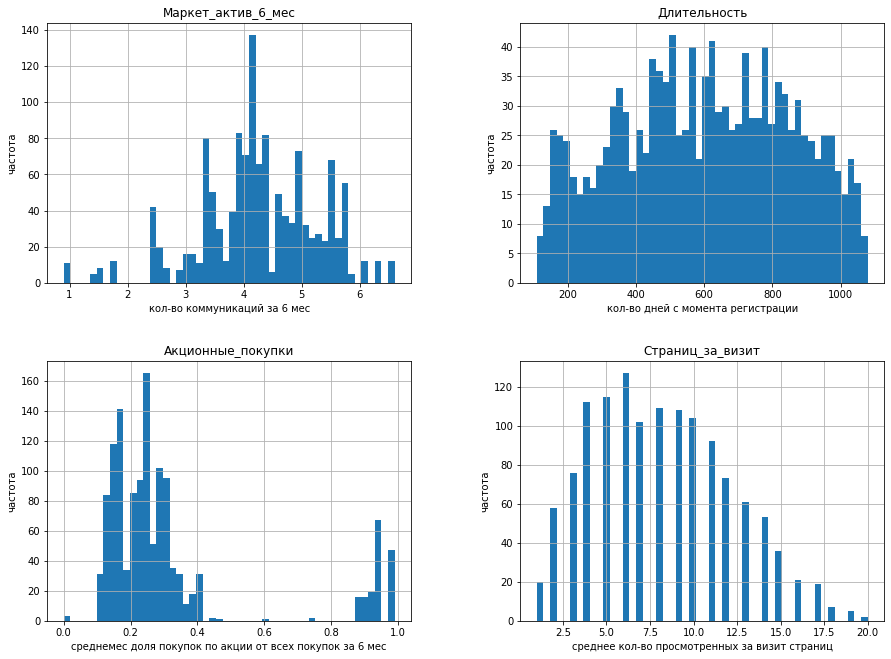

In [18]:
# количественные непрерывные признаки таблицы df_market
ax = df_market.hist(column=['Маркет_актив_6_мес', 'Длительность', \
                           'Акционные_покупки', \
                            'Страниц_за_визит'],bins=50, figsize=(15,11),)
x_labels=['кол-во коммуникаций за 6 мес', \
         'кол-во дней с момента регистрации', \
         'среднемес доля покупок по акции от всех покупок за 6 мес', \
         'среднее кол-во просмотренных за визит страниц']
for i, ax in enumerate(ax.flatten()):
    ax.set_xlabel(x_labels[i])
    ax.set_ylabel('частота')

Text(0.5, 1.0, 'кол-во страниц, просмотренных за один визит')

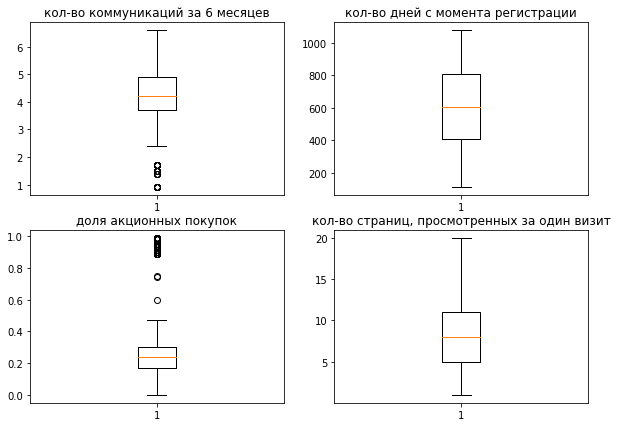

In [19]:
fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(10,7))
axes[0,0].boxplot(df_market['Маркет_актив_6_мес'])
axes[0,0].set_title('кол-во коммуникаций за 6 месяцев')
axes[0,1].boxplot(df_market['Длительность'])
axes[0,1].set_title('кол-во дней с момента регистрации')
axes[1,0].boxplot(df_market['Акционные_покупки'])
axes[1,0].set_title('доля акционных покупок')
axes[1,1].boxplot(df_market['Страниц_за_визит'])
axes[1,1].set_title('кол-во страниц, просмотренных за один визит')

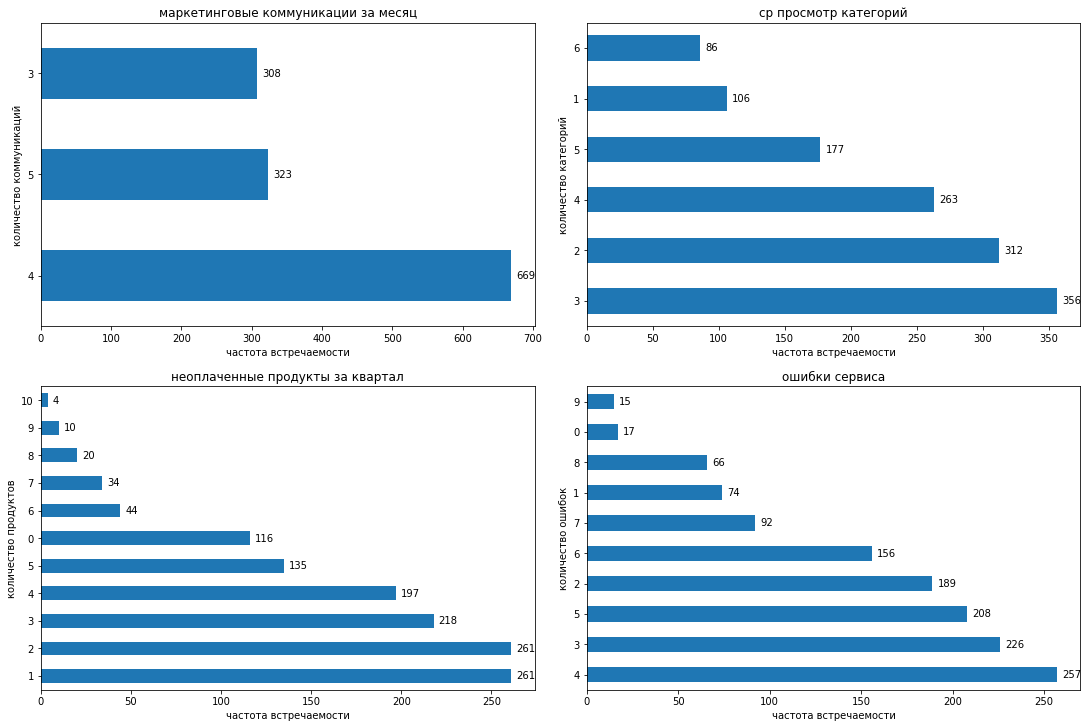

In [20]:
# количественные дискретные признаки таблицы df.market
fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(15,10), constrained_layout=True)
df_market['Маркет_актив_тек_мес'].value_counts().plot(kind='barh', ax=axes[0,0], \
                                    title='маркетинговые коммуникации за месяц',\
                                    ylabel='количество коммуникаций')
axes[0,0].set_xlabel('частота встречаемости')
df_market['Средний_просмотр_категорий_за_визит'].value_counts().plot(kind='barh',\
                                            ax=axes[0,1],
                                            title='ср просмотр категорий',\
                                            ylabel='количество категорий')
axes[0,1].set_xlabel('частота встречаемости')
df_market['Неоплаченные_продукты_штук_квартал'].value_counts().plot(kind='barh',\
                                            ax=axes[1,0],
                                            title='неоплаченные продукты за квартал',\
                                            ylabel='количество продуктов')
axes[1,0].set_xlabel('частота встречаемости')
df_market['Ошибка_сервиса'].value_counts().plot(kind='barh', ax=axes[1,1], \
                                            title='ошибки сервиса',\
                                            ylabel='количество ошибок')
axes[1,1].set_xlabel('частота встречаемости')
for ax in axes.flatten():
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f'{width}', (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5,0),
                textcoords='offset points')

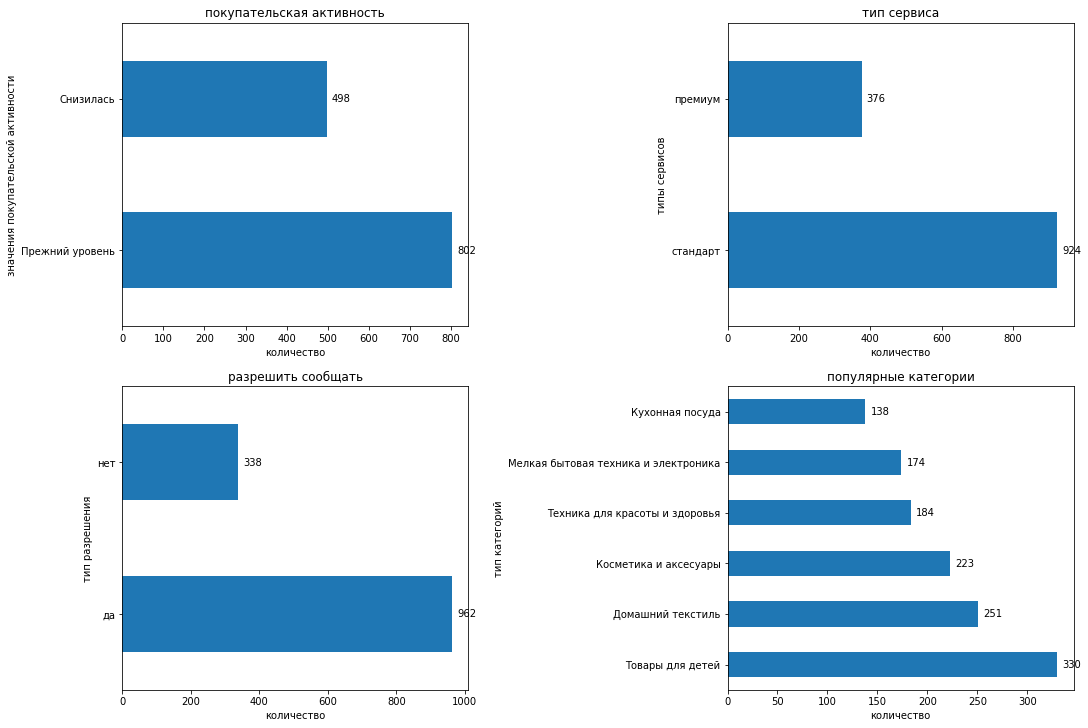

In [21]:
# категориальные признаки таблицы df.market
fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(15,10), constrained_layout=True)
df_market['Покупательская_активность'].value_counts().plot(kind='barh', ax=axes[0,0], \
                                        title='покупательская активность',\
                                        ylabel='значения покупательской активности')
axes[0,0].set_xlabel('количество')
df_market['Тип_сервиса'].value_counts().plot(kind='barh', ax=axes[0,1], \
                                                title='тип сервиса',\
                                            ylabel='типы сервисов')
axes[0,1].set_xlabel('количество')
df_market['Разрешить_сообщать'].value_counts().plot(kind='barh', ax=axes[1,0], \
                                                title='разрешить сообщать',\
                                            ylabel='тип разрешения')
axes[1,0].set_xlabel('количество')
df_market['Популярная_категория'].value_counts().plot(kind='barh', ax=axes[1,1], \
                                                title='популярные категории',\
                                            ylabel='тип категорий')
axes[1,1].set_xlabel('количество')
for ax in axes.flatten():
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f'{width}', (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5,0),
                textcoords='offset points')

В результате исследовательского анализа данных с таблицы df_market можно заметить следующие зависимости:
- часть непрерывных величин имеют нормальное распределение (маркет_актив_6_мес), но некоторые из них немного смещены влево (страниц_за_визит); распределение величин "акционные_покупки" и "длительность" далеки от нормального.
- в столбцах "маркет_актив_6_мес" и "акционные_покупки" есть выбросы (в первом случае - значения меньше 2, вто втором - значения больше 0,5). Их удалять не нужно, так как они хоть и реже встречаются, но необходимы для дальнейшей корректной работы модели
- количественные дискретные величины: чаще всего магазин совершает 4 коммуникации с пользователем в месяц (669 случаев), реже - 3 или 5; пользователь чаще всего рассматривает 3 категории за визит (356 случаев), реже всего - 6 или 1 категорию; чаще всего у пользователя в корзине по 1 или 2 неоплаченных продукта (по 261 случаю), реже  всего - 8, 9, 10. Это говорит о том, что пользователи либо сразу оплачивают все товары, либо не предпочитают оставлять запланированные покупки в корзине (например, переносят в "избранное"). В большинстве случаев пользователи сталкивались с 3-4 ошибками сервиса, реже всего 9 и 0, это говорит о том, что ошибки в этом магазине - не редкость и их необходимо устранять для того, чтобы не потерять лояльность пользователей
- категориальные величины: у большинства пользователей покупательская активность осталась на прежнем уровне (802), у 498 пользователей снизилась; у большинства пользователей тип сервиса - стандарт (924 пользователя), у 376 - премиум; большинство покупателей (962) разрешают присылать дополнительные предложения о товаре; самые популярные категории покупок - товары для детей, домашний текстиль и косметика и аксессуары, исходя из этого можно сформулировать гипотезу, что большинство покупателей - женщины среднего возраста с детьми.

This figure was using constrained_layout==True, but that is incompatible with subplots_adjust and or tight_layout: setting constrained_layout==False. 


Text(0.5, 1.0, 'выручка за препредыдущий месяц')

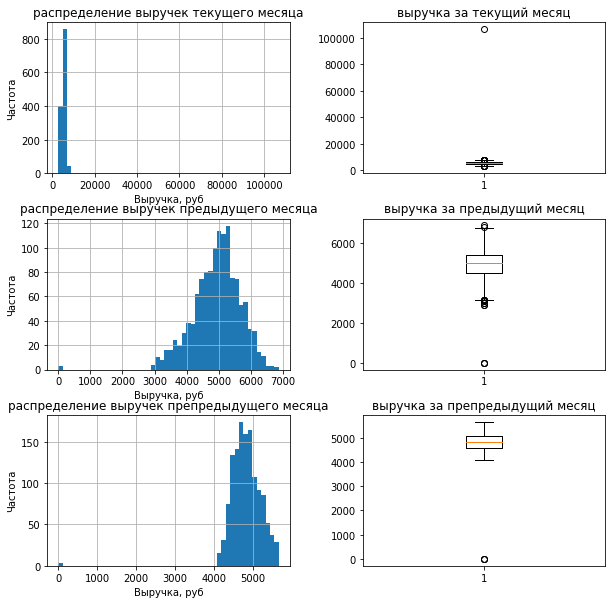

In [22]:
fig, ax = plt.subplots(ncols=2, nrows=3, figsize=(10,10), constrained_layout=True)
df_market_money[df_market_money['Период'] == 'текущий_месяц'].hist(column='Выручка', 
                                                                   bins=50, ax=ax[0,0])
ax[0,0].set_title('распределение выручек текущего месяца')
ax[0,0].set_xlabel('Выручка, руб')
ax[0,0].set_ylabel('Частота')
df_market_money[df_market_money['Период'] == 'предыдущий_месяц'].hist(column='Выручка', 
                                                                      bins=50, ax=ax[1,0])
ax[1,0].set_title('распределение выручек предыдущего месяца')
ax[1,0].set_xlabel('Выручка, руб')
ax[1,0].set_ylabel('Частота')
df_market_money[df_market_money['Период'] == 'препредыдущий_месяц'].hist(column='Выручка',
                                                                         bins=50, ax=ax[2,0])
ax[2,0].set_title('распределение выручек препредыдущего месяца')
ax[2,0].set_xlabel('Выручка, руб')
ax[2,0].set_ylabel('Частота')

ax[0,1].boxplot(df_market_money[df_market_money['Период'] == 'текущий_месяц']['Выручка'])
ax[0,1].set_title('выручка за текущий месяц')

ax[1,1].boxplot(df_market_money[df_market_money['Период'] == 'предыдущий_месяц']['Выручка'])
ax[1,1].set_title('выручка за предыдущий месяц')

ax[2,1].boxplot(df_market_money[df_market_money['Период'] == 'препредыдущий_месяц']['Выручка'])
ax[2,1].set_title('выручка за препредыдущий месяц')


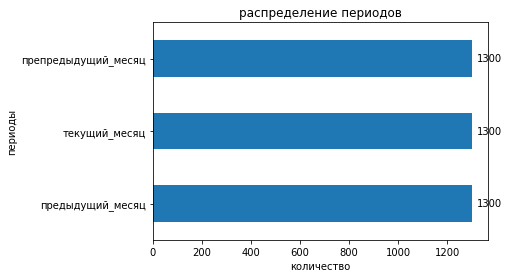

In [23]:
ax = df_market_money['Период'].value_counts().plot(kind='barh', 
                                              title='распределение периодов', 
                                              xlabel='периоды')
ax.set_xlabel('количество')
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width}', (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5,0),
                textcoords='offset points')

В результате исследовательского анализа данных таблицы df_market_money можно заметить следующие зависимости:
- периоды распределены одинаково - по 1300 случаев на каждый месяц
- в каждом из периодов есть выбросы - в текущем месяце значение больше 100 тыс, в предыдущем и препредыдущем месяце - 0

This figure was using constrained_layout==True, but that is incompatible with subplots_adjust and or tight_layout: setting constrained_layout==False. 


Text(0.5, 1.0, 'минуты за предыдущий месяц')

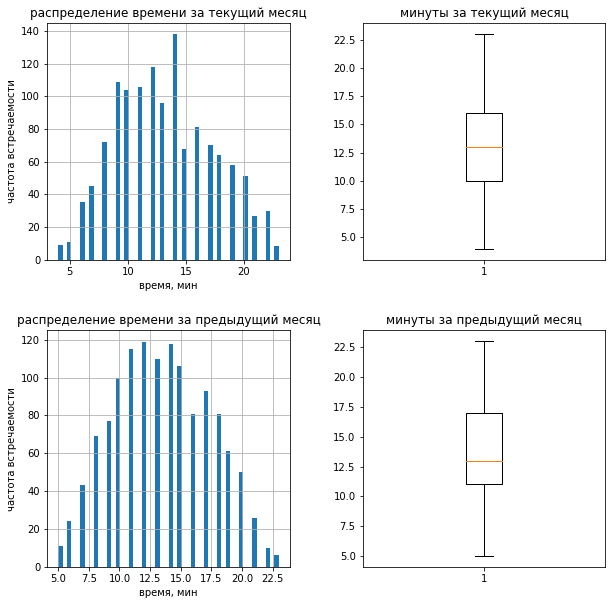

In [81]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10,10), constrained_layout=True)

df_time[df_time['Период'] == 'текущий_месяц'].hist(column='Минут', bins=50, ax=ax[0,0])
ax[0,0].set_title('распределение времени за текущий месяц')
ax[0,0].set_xlabel('время, мин')
ax[0,0].set_ylabel('частота встречаемости')

df_time[df_time['Период'] == 'предыдущий_месяц'].hist(column='Минут', bins=50, ax=ax[1,0])
ax[1,0].set_title('распределение времени за предыдущий месяц')
ax[1,0].set_xlabel('время, мин')
ax[1,0].set_ylabel('частота встречаемости')

ax[0,1].boxplot(df_time[df_time['Период'] == 'текущий_месяц']['Минут'])
ax[0,1].set_title('минуты за текущий месяц')

ax[1,1].boxplot(df_time[df_time['Период'] == 'предыдущий_месяц']['Минут'])
ax[1,1].set_title('минуты за предыдущий месяц')

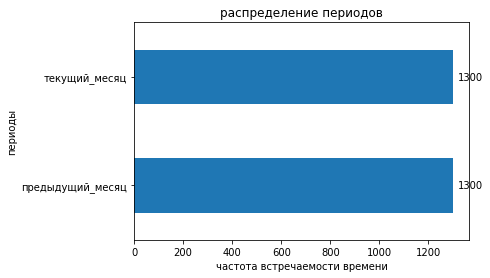

In [25]:
ax = df_time['Период'].value_counts().plot(kind='barh')
plt.title('распределение периодов')
plt.xlabel('частота встречаемости времени')
plt.ylabel('периоды')
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width}', (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5,0),
                textcoords='offset points')

В результате исследования таблицы df_time можно заметить следующие зависимости:
- время в минутах, проведенное пользователями на сайте, имеет нормальное распределение за каждый период, судя по гистограмме выбросов нет
- периоды, указанные в датафрейме, разделены равномерно - по 1300 значений на каждый период

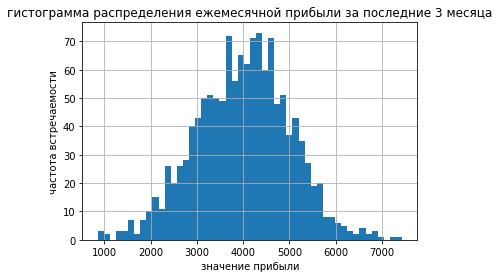

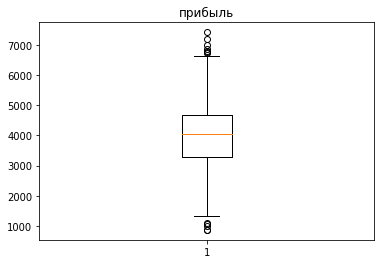

In [85]:
df_money.hist(column='Прибыль', bins=50)
plt.title('гистограмма распределения ежемесячной прибыли за последние 3 месяца')
plt.xlabel('значение прибыли')
plt.ylabel('частота встречаемости')
plt.show()

plt.boxplot(df_money['Прибыль'])
plt.title('прибыль')
plt.show()

В результате исследования прибыли в таблице df_money можно заметить, что значение прибыли распределено нормально. Есть несколько выбросов - значения больше 6500 и значения меньше 1500.

In [27]:
# отделяем клиентов, которые совершали покупки в течение 3 месяцев
df_market_money_new = df_market_money_new[(df_market_money_new['предыдущий_месяц'] != 0)
                                        & (df_market_money_new['препредыдущий_месяц'] != 0)
                                        & (df_market_money_new['текущий_месяц'] != 0)]
df_market_money_new.sort_values(by='Сумма', ascending=False).head()


Период,id,предыдущий_месяц,препредыдущий_месяц,текущий_месяц,Сумма
32,215380,6077.0,5051.0,106862.2,117990.2
493,215841,6588.5,5621.0,7557.0,19766.5
87,215435,6869.5,5008.0,7605.3,19482.8
145,215493,6716.5,4870.0,7799.4,19385.9
796,216144,6337.5,5091.0,7547.8,18976.3


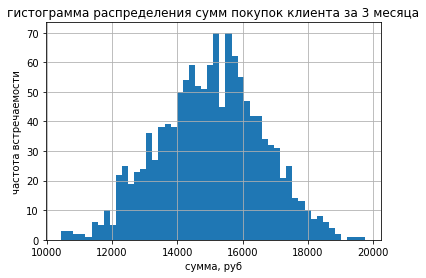

Text(0.5, 1.0, 'сумма покупок за 3 месяца')

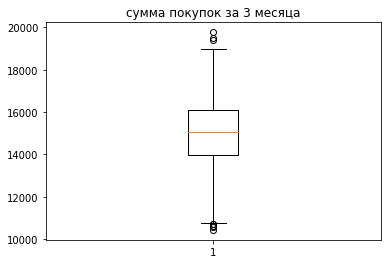

In [86]:
df_market_money_new.hist(column='Сумма', bins=50)
plt.title('гистограмма распределения сумм покупок клиента за 3 месяца')
plt.xlabel('сумма, руб')
plt.ylabel('частота встречаемости')
df_market_money_new = df_market_money_new[df_market_money_new['Сумма'] < 100000]
plt.show()

plt.boxplot(df_market_money_new['Сумма'])
plt.title('сумма покупок за 3 месяца')

Исходя из гистограмм распределения сумм покупок клиентов за 3 месяца (среди тех, кто совершал покупки в каждый месяц без пропусков) можно сделать вывод, что распределение сумм близко к нормальному (но немного сужено), также можно заметить, что в данных есть аномальное значение - сумма покупок, равная 117990р. Его нужно удалить. Также есть несколько выбросов - значения больше 19000 и значения меньше 11000.

## Объединение таблиц

In [29]:
# создаем датафреймы с разделенными столбцами для каждого периода
df_time_columns = df_time.pivot_table(index='id', columns='Период', values='Минут')
df_time_columns.columns = ['время_предыдущий_месяц', 'время_текущий_месяц']


In [30]:
print(f'{len(df_market)}/{df_market["id"].isin(df_market_money_new["id"]).sum()} \
значений id датафрейма df_market есть в датафрейме df_market_money_new')
print(f'{len(df_market)}/{df_market["id"].isin(df_time["id"]).sum()} \
значений id датафрейма df_market есть в датафрейме df_time')
df1= df_market.merge(df_time_columns, on='id')
print(f'Количество пропусков в новом датафрейме df1 \n{df1.isna().sum()}')
df = df1.merge(df_market_money_new, on='id', how='right')
print(f'Количество пропусков в итоговом датафрейме df \n{df.isna().sum()}')
print(f'Параметры итогового датафрейма df {df.shape}')
df = df.rename(columns={'предыдущий_месяц':'выручка_предыдущий_месяц',
               'текущий_месяц':'выручка_текущий_месяц',
               'препредыдущий_месяц':'выручка_препредыдущий_месяц'})
df = df.drop(columns='Сумма')
df.head()

1300/1296 значений id датафрейма df_market есть в датафрейме df_market_money_new
1300/1300 значений id датафрейма df_market есть в датафрейме df_time
Количество пропусков в новом датафрейме df1 
id                                     0
Покупательская_активность              0
Тип_сервиса                            0
Разрешить_сообщать                     0
Маркет_актив_6_мес                     0
Маркет_актив_тек_мес                   0
Длительность                           0
Акционные_покупки                      0
Популярная_категория                   0
Средний_просмотр_категорий_за_визит    0
Неоплаченные_продукты_штук_квартал     0
Ошибка_сервиса                         0
Страниц_за_визит                       0
время_предыдущий_месяц                 0
время_текущий_месяц                    0
dtype: int64
Количество пропусков в итоговом датафрейме df 
id                                     0
Покупательская_активность              0
Тип_сервиса                            0
Разреши

,id,Покупательская_активность,Тип_сервиса,Разрешить_сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,время_предыдущий_месяц,время_текущий_месяц,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,12,10,5216.0,4472.0,4971.6
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,8,13,5457.5,4826.0,5058.4
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,11,13,6158.0,4793.0,6610.4
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,8,11,5807.5,4594.0,5872.5
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,10,10,4738.5,5124.0,5388.5


Таблицы df_market, df_market_money и df_time были объединены в один датафрейм df, дополнительно были проверены пропуски в получившемся датафрейме и его размерность: пропусков не оказалось и размерность изменилась за счет одного аномального значения и трех тех, где выручка есть не за каждый месяц.

## Корреляционный анализ

,id,Покупательская_активность,Тип_сервиса,Разрешить_сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,время_предыдущий_месяц,время_текущий_месяц,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц
id,1.000000,0.984597,0.116473,0.019783,0.466290,0.000000,0.050714,0.413956,0.171846,0.353945,0.314345,0.204583,0.608831,0.564878,0.473579,0.238373,0.421755,0.173750
Покупательская_активность,0.984597,1.000000,0.129940,0.000000,0.544831,0.000000,0.099901,0.506276,0.299717,0.539607,0.405041,0.224154,0.749888,0.685138,0.576770,0.224638,0.497393,0.197213
Тип_сервиса,0.116473,0.129940,1.000000,0.289965,0.089911,0.045258,0.401411,0.030010,0.070809,0.185391,0.113015,0.079515,0.102594,0.131814,0.000000,0.000000,0.069704,0.124216
Разрешить_сообщать,0.019783,0.000000,0.289965,1.000000,0.000000,0.052618,0.253831,0.012198,0.073684,0.070359,0.162524,0.021839,0.042134,0.038387,0.000000,0.080842,0.000000,0.060907
Маркет_актив_6_мес,0.466290,0.544831,0.089911,0.000000,1.000000,0.079854,0.000000,0.279553,0.150386,0.206788,0.217731,0.142401,0.396769,0.363950,0.330601,0.155476,0.315331,0.039795
Маркет_актив_тек_мес,0.000000,0.000000,0.045258,0.052618,0.079854,1.000000,0.174233,0.000000,0.136243,0.246633,0.142887,0.116946,0.000000,0.107945,0.061410,0.051824,0.000000,0.000000
Длительность,0.050714,0.099901,0.401411,0.253831,0.000000,0.174233,1.000000,0.000000,0.000000,0.186795,0.128222,0.175608,0.122495,0.026448,0.101481,0.125572,0.113200,0.147048
Акционные_покупки,0.413956,0.506276,0.030010,0.012198,0.279553,0.000000,0.000000,1.000000,0.122385,0.199180,0.246665,0.000000,0.311418,0.262324,0.250558,0.060733,0.226381,0.071094
Популярная_категория,0.171846,0.299717,0.070809,0.073684,0.150386,0.136243,0.000000,0.122385,1.000000,0.226116,0.254746,0.000000,0.160300,0.195233,0.089883,0.252097,0.043528,0.237240
Средний_просмотр_категорий_за_визит,0.353945,0.539607,0.185391,0.070359,0.206788,0.246633,0.186795,0.199180,0.226116,1.000000,0.334927,0.070315,0.262271,0.159837,0.182568,0.098440,0.176828,0.092597


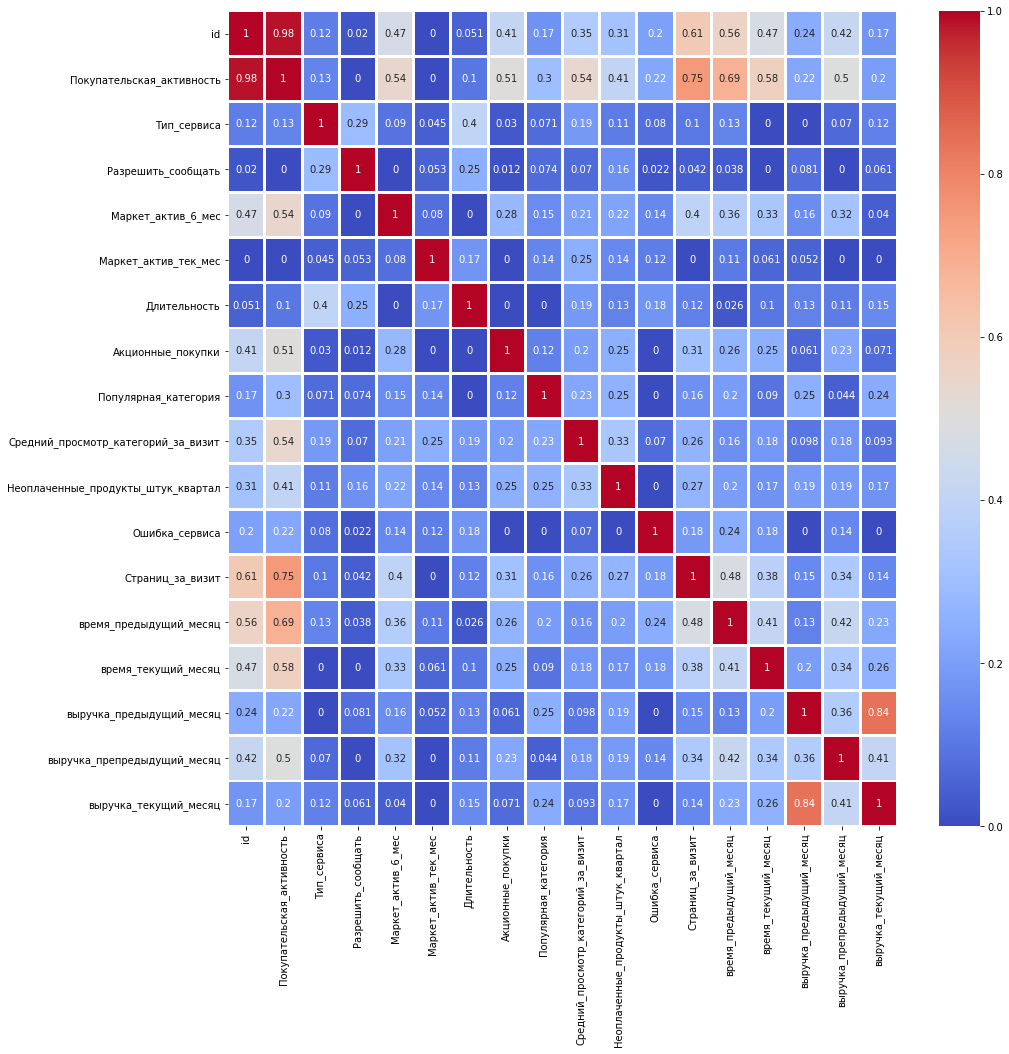

In [31]:

matrix = df.phik_matrix(interval_cols=['Длительность','Маркет_актив_6_мес',
                             'Маркет_актив_тек_мес', 'Акционные_покупки',
                             'Средний_просмотр_категорий_за_визит',
                             'Ошибка_сервиса', 'Страниц_за_визит',
                             'выручка_предыдущий_месяц', 'выручка_текущий_месяц',
                             'выручка_препредыдущий_месяц', 'время_текущий_месяц',
                             'время_предыдущий_месяц', 'id'])
plt.figure(figsize=(15, 15))
sns.heatmap(matrix, cmap='coolwarm', annot=True, linewidths=2)
matrix

В результате корреляционного анализа признаков можно сделать следующие выводы:
- целевой признак покупательская_активность больше всего зависит от признаков страниц_за_визит, время_предыдущий_месяц и время_текущий_месяц. То есть покупательская активность напрямую зависит от взаимодействия пользователя с сайтом;
- мультиколлинеарности среди признаков нет, так как нет значения корреляции выше 0.93-0.95

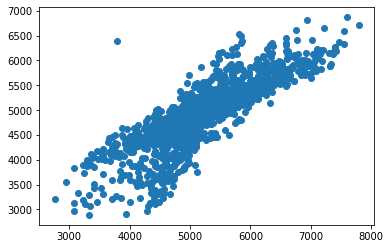

In [32]:
plt.scatter(df['выручка_текущий_месяц'], df['выручка_предыдущий_месяц'])

Исходя из диаграммы рассеяния между выручкой за текущий и предыдущий месяцы можно сделать вывод, что между ними высокая линейная зависимость, то есть исходя из одного признака можно предсказать другой. Это подтверждает и высокий коэффициент корреляции - 0.84. 

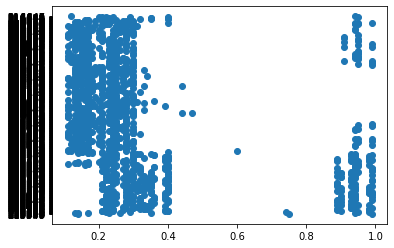

In [33]:
plt.scatter(df['Акционные_покупки'], df['id'])

Большинство пользователей либо часто покупают товары по акции, либо наоборот редко. Одинаковое количество покупок по акции и без акций встречается редко. 

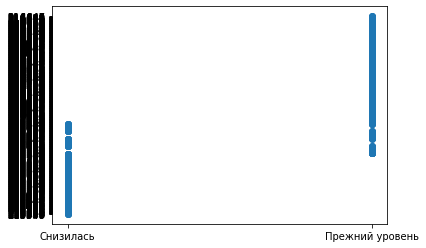

In [34]:
plt.scatter(df['Покупательская_активность'], df['id'])

Возможно, пользователи с более высоким значением id зарегистрировались позднее, чем пользователи с более маленьким значением id. По диаграмме рассеяния видно, что у первой группы пользователей активность остается на прежнем уровне, а у второй она снижается. Возможно, это связано с тем, что пользователи, зарегистрировавшиеся ранее уже не нуждаются в товарах интернет-магазина, либо нашли тот магазин, где лучше условия. 

## Использование пайплайнов

In [35]:
df.head()

,id,Покупательская_активность,Тип_сервиса,Разрешить_сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,время_предыдущий_месяц,время_текущий_месяц,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,12,10,5216.0,4472.0,4971.6
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,8,13,5457.5,4826.0,5058.4
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,11,13,6158.0,4793.0,6610.4
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,8,11,5807.5,4594.0,5872.5
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,10,10,4738.5,5124.0,5388.5


In [36]:
X = df.drop(['Покупательская_активность', 'id',
            'Разрешить_сообщать', 'Маркет_актив_тек_мес',
            'выручка_текущий_месяц'], axis=1)
y = df['Покупательская_активность']
print(f'Проверяем сбалансированны ли классы целевого признака \n{y.value_counts()}')

Проверяем сбалансированны ли классы целевого признака 
Прежний уровень    802
Снизилась          494
Name: Покупательская_активность, dtype: int64


Для последующего обучения модели были отобраны только те признаки, которые непосредственно влияют на целевой. Некоторые признаки были отброшены для того, чтобы модель не искала зависимостей там, где их нет.

Классы оказались несбалансированы - покупателей с прежним уровнем активности 802, со сниженным уровнем - 498. Это будет учитано при разделении признаков на выборки и при подборе гиперпараметров.

In [37]:
cat_columns = ['Тип_сервиса', 'Популярная_категория']
num_columns = ['Маркет_актив_6_мес', 'Длительность',
              'Акционные_покупки', 'Средний_просмотр_категорий_за_визит',
              'Неоплаченные_продукты_штук_квартал', 'Ошибка_сервиса',
              'Страниц_за_визит', 'время_предыдущий_месяц',
               'выручка_предыдущий_месяц', 'выручка_препредыдущий_месяц', 
               'время_текущий_месяц']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                   random_state=42, stratify=y)

In [39]:
ohe_pipe = Pipeline(
[
    ('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

one_pipe = Pipeline(
[
    ('simpleImputer_one_before', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
    ('one', OrdinalEncoder(handle_unknown='use_encoded_value', 
                           unknown_value=np.nan)),
    ('simpleImputer_one_after', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
])

In [40]:
data_preprocessor = ColumnTransformer(
[
    ('cat', ohe_pipe, cat_columns),
    ('num', StandardScaler(), num_columns)
],
    remainder='passthrough'
)

pipe_final = Pipeline(
[
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=42))
]
)
pipe_final.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Тип_сервиса',
                                                   'Популярная_категория']),
                                                 ('num', StandardScaler(),
                                                  ['Маркет_актив_6_мес',
                                                   'Длительность',
                                                   'Акционные_покупки',
                                                   'Средний_просмотр_категорий_за_визит',
                                                   'Неоплаченные_продукты_штук_квартал',
                                                   'Ошибка_сервиса',
                                                   'Страниц_за_визит',
                                                   'время_предыдущий_месяц',
                                                   'выручка_предыдущий_месяц',
                                                   'выручка_препредыдущий_месяц',
                                                   'время_текущий_месяц'])])),
                ('models', DecisionTreeClassifier(random_state=42))])

In [41]:
param_grid = [
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(1, 10),
        'preprocessor__num':[StandardScaler(), MinMaxScaler()],
        'preprocessor__cat':[one_pipe, ohe_pipe]
    },
    {
        'models': [DecisionTreeClassifier(random_state=42)],
        'models__max_depth': range(2, 11),
        'models__max_features': range(2, 5),
        'preprocessor__num':[StandardScaler(), MinMaxScaler()],
        'preprocessor__cat':[one_pipe, ohe_pipe]
    },
    {
        'models': [SVC(probability=True, random_state=42)],
        'models__C': range(1, 5),
        'models__gamma': range(1,5),
        'preprocessor__num':[StandardScaler(), MinMaxScaler()],
        'preprocessor__cat':[one_pipe, ohe_pipe]
    },
    {
        'models': [LogisticRegression(random_state=42, solver='liblinear',
                                     penalty='l1')],
        'models__C': range(1, 5),
        'preprocessor__num':[StandardScaler(), MinMaxScaler()],
        'preprocessor__cat':[one_pipe, ohe_pipe]
    }    
]

randomized_search = RandomizedSearchCV(
    pipe_final,
    param_grid,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)
randomized_search.fit(X_train, y_train)

print('Лучшая модель и ее параметры \n', randomized_search.best_params_)
print('Метрика лучшей модели при кросс-валидации:', randomized_search.best_score_)

Лучшая модель и ее параметры 
 {'preprocessor__num': MinMaxScaler(), 'preprocessor__cat': Pipeline(steps=[('simpleImputer_one_before',
                 SimpleImputer(strategy='most_frequent')),
                ('one',
                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                unknown_value=nan)),
                ('simpleImputer_one_after',
                 SimpleImputer(strategy='most_frequent'))]), 'models__C': 4, 'models': LogisticRegression(penalty='l1', random_state=42, solver='liblinear')}
Метрика лучшей модели при кросс-валидации: 0.8989146402600948


In [42]:
print('roc-auc тестовой выборки:', 
      roc_auc_score(y_test, randomized_search.predict_proba(X_test)[:,1]))

roc-auc тестовой выборки: 0.9163531933826801


В результате перебора методов кодирования и масштабирования, моделей и ее  гиперпараметров лучший результат - модель LogisticRegression с C=4. Roc-auc на кросс-валидации - 0.9, на тестовой - 0.92. Переобучения или недообучения нет.

С точки зрения бизнеса важнее метрика recall: класс 1 должен быть присвоен как можно большему числу пользователей для того, чтобы предотвратить заранее снижение активности.
roc-auc используется конкретно в этой задаче, так как он не зависит от порога классификации и устойчив при дисбалансе классов.

## Анализ важности признаков

<AxesSubplot:ylabel='Feature'>

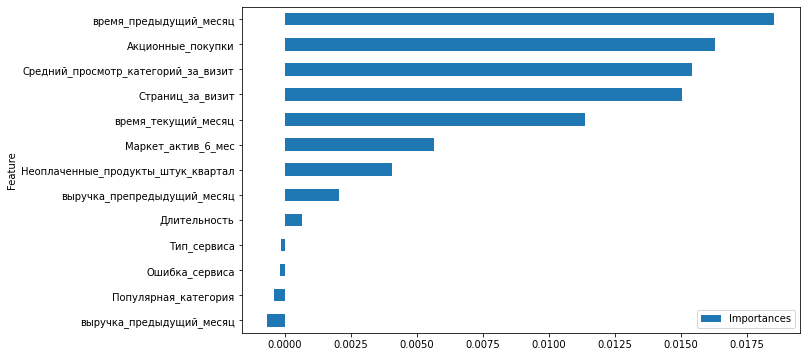

In [43]:
result = permutation_importance(randomized_search,
                                X_test, y_test, scoring='roc_auc')
feature_importance = pd.DataFrame({'Feature' : X_test.columns,
                                   'Importances' : result['importances_mean']})
feature_importance = feature_importance.sort_values(by='Importances')
feature_importance.plot(x='Feature', y='Importances', kind='barh', figsize=(10,6))

In [44]:
X_train_transformed = randomized_search.best_estimator_.named_steps['preprocessor'].fit_transform(X_train)
X_test_transformed = randomized_search.best_estimator_.named_steps['preprocessor'].transform(X_test)
print(X_train_transformed)


[[1.         3.         0.80701754 ... 0.57306194 0.15910543 0.10526316]
 [1.         4.         0.73684211 ... 0.88202035 0.31884984 0.47368421]
 [1.         3.         0.59649123 ... 0.30732504 0.33738019 0.31578947]
 ...
 [1.         5.         0.77192982 ... 0.6235708  0.7514377  0.78947368]
 [1.         3.         0.64912281 ... 0.49553964 0.56677316 0.84210526]
 [1.         3.         0.42105263 ... 0.50860661 0.76677316 0.52631579]]


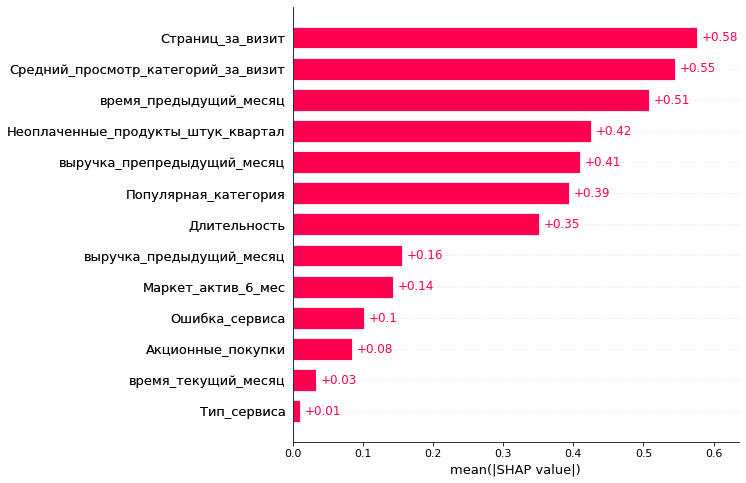

In [52]:
explainer = shap.LinearExplainer(randomized_search.best_estimator_.named_steps['models'],
                                 X_train_transformed, feature_names=X_train.columns)
shap_values = explainer(X_test_transformed)
shap.plots.bar(shap_values, max_display=17)

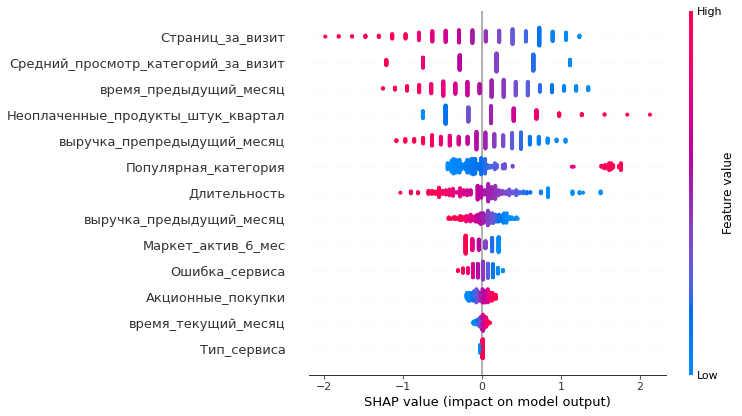

In [53]:
shap.plots.beeswarm(shap_values, max_display=17)

Исходя из оценки значимости признаков можно сделать следующие выводы: 
- больше всего на целевой признак "Покупательская_активность" влияют следующие признаки: кол-во страниц, просмотренное за визит, время, проведенное на сайте за предыдущий месяц, средний просмотр категорий за визит;
- чем больше значения страниц_за_визит, время_предыдущий_месяц, время_препредыдущий_месяц, средний_просмотр_категорий_за_визит тем больше вероятность принадлежности к классу 0 (прежний уровень)
- чем больше значение неоплаченные_продукты_штук_квартал, тем больше вероятность принадлежности к классу 1 (снизилась).

## Сегментация покупателей

Рассмотрим сегмент: группа клиентов, которые покупают только технику

In [54]:
#проверяем, что класс 1 - сниженная покупательская активность
randomized_search.classes_

array(['Прежний уровень', 'Снизилась'], dtype=object)

In [71]:
# кодируем и масштабируем все входные признаки для дальнейшего анализа сегмента
X_transformed = randomized_search.best_estimator_.named_steps['preprocessor'].transform(X)
df['predict'] = randomized_search.best_estimator_.named_steps['models'].predict_proba(X_transformed)[:,1]
df_new = df[df['Популярная_категория'] == 'Мелкая бытовая техника и электроника']['predict']
df_new.sort_values(ascending=False)
df['Сегмент'] = df['Популярная_категория'].apply(lambda x: 'наш_сегмент' 
                                                 if (x=='Мелкая бытовая техника и электроника')
                                                 or (x=='Техника для красоты и здоровья')
                                                else 'не_наш_сегмент')
df = df.merge(df_money, how='left')

Text(0.5, 1.0, 'Гистограмма распределения вероятности снижения активности')

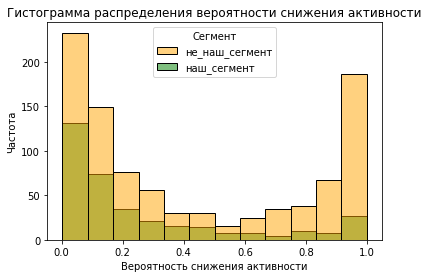

In [76]:
sns.histplot(data=df, x='predict', hue='Сегмент', palette=['orange', 'green'])
plt.xlabel('Вероятность снижения активности')
plt.ylabel('Частота')
plt.title('Гистограмма распределения вероятности снижения активности')

Исходя из гистограммы в сравнении с остальными сегментами можно сделать вывод, что в рассматриваемом нами сегменте (техника: мелкая бытовая техника и электроника, техника для красоты и здоровья) реже встречается большая вероятность снижения активности (то есть у большинства клиентов активность остается прежней)

Text(0.5, 1.0, 'Диаграмма рассеяния вероятности снижения активности и прибыли')

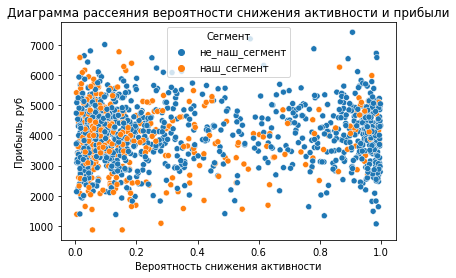

In [73]:
sns.scatterplot(data=df, x='predict', y='Прибыль',hue='Сегмент')
plt.xlabel('Вероятность снижения активности')
plt.ylabel('Прибыль, руб')
plt.title('Диаграмма рассеяния вероятности снижения активности и прибыли')

В рассматриваемом нами сегменте достаточно большой разброс прибыли по сравнению с остальными сегментами. Большую часть клиентов с высокой прибыльностью составляют клиенты с рассматриваемого нами сегмента. Чаще всего встречаемое значение прибыли как и для остальных сегментов 3000-5000р. Вероятность снижения активности у клиентов, покупающих технику, в большинстве случаев мала.


Решить проблему снижения покупательской активности можно следующими методами:
- отправка дополнительных промокодов и акционных предложений таким пользователями - возможно, благодаря этому они будут покупать больше различной техники для дома
- при большой сумме покупок отправлять небольшие пробники и промокод на скидку для покупки полноразмерного товара (пример: при покупке стиральной машины отправлять пробник порошка/гелей для стирки и промокод на скидку), это действие позволит "переманить" покупателей на покупку товаров из других категорий.
- разработать контексную рекламу на сайте (пример: при покупке фена предлагать пользователю купить расческу)


## Итоговый вывод

В качестве исходных данных были переданы следующие датафреймы:
 - market_file.csv - таблица с данными о поведении покупателя на сайте, о коммуникациях с покупателем и его продуктовом поведении; 
 - market_money.csv - таблица с данными о выручке, которую получает магазин с покупателя;
 - market_time.csv - таблица с данными о времени (в минутах), которое покупатель провёл на сайте в течение периода;
 - money.csv - таблица с данными о среднемесячной прибыли продавца за последние 3 месяца: какую прибыль получает магазин от продаж каждому покупателю.
 
В данных были обнаружены следующие проблемы: 
- в данных market_file.csv - неявные дубликаты в столбце тип_сервиса
- в данных market_time.csv - опечатка в названии периода ("предыдцщий_месяц" было исправлено на "предыдущий_месяц")
- в данных money.csv - аномальные значения прибыли (для дальнейшей работы все значения были умножены на 1000)

В результате исследовательского анализа данных получились следующие выводы:
- большинство непрерывных количественных величин имеют далеко от нормального распределение, в некоторых из них есть выбросы и несколько вершин
- чаще всего магазин совершает 4 коммуникации с пользователем, реже - 3 или 5; чаще всего у пользователя в корзине по 1 или 2 неоплаченных продукта, реже всего - 8, 9, 10; большинство пользователей сталкивались с 3-4 ошибкмии сервиса, реже всего 9 и 0.
- у большинства пользователей покупательская активность осталась на прежнем уровне (у 802), у 498 пользователей снизилась; у большинства (924 пользователя) тип сервисастандарт, у остальных - премиум; большинство покупателей (962) разрешают присылать дополнительные предложения о товаре

В результате корреляционного анализа данных можно сделать следующий вывод:

Целевой признак "Покупательская_активность" в большей степени зависит от признаков страниц_за_визит, время_предыдущий_месяц и время_текущий_месяц. То есть покупательская активность напрямую зависит от взаимодействия пользователя с сайтом. Мультиколлинеарности среди признаков нет, так как нет значения корреляции выше 0.93-0.95

В результате использования пайплайнов вышло, что самая лучшая модель LogisticRegression с гиперпараметрами c=4. Лучший метод кодирования категориальных признаков - OrdinalEncoder, лучший метод масштабирования количественных признаков - MinMaxScaler.

В результате исследования в задаче сегментации можно сделать следующие выводы:

- рассматриваемом нами сегменте (техника: мелкая бытовая техника и электроника, техника для красоты и здоровья) реже встречается большая вероятность снижения активности (то есть у большинства клиентов активность остается прежней)
- в рассматриваемом нами сегменте достаточно большой разброс прибыли по сравнению с остальными сегментами. Большинство значений прибыли как и для остальных сегментов 3000-5000р.


В задаче сегментации была рассмотрена группа пользователей, которая в основном покупает технику, для повышения пользовательской активности были сформулированы следующие рекомендации:

- отправка дополнительных промокодов и акционных предложений таким пользователями - возможно, благодаря этому они будут покупать больше различной техники для дома
- при большой сумме покупок отправлять небольшие пробники и промокод на скидку для покупки полноразмерного товара (пример: при покупке стиральной машины отправлять пробник порошка/гелей для стирки и промокод на скидку), это действие позволит "переманить" покупателей на покупку товаров из других категорий.
- разработать контексную рекламу на сайте (пример: при покупке фена предлагать пользователю купить расческу)

Общие рекомендации компании:
- добавить больше признаков, которые помогут повысить точность модели. Например, количество написанных пользователем отзывов; среднее за месяц количество покупок; средняя стоимость таких покупок; способ, по которому пользователь нашел магазин (по совету, из интернета и т.д.); возрастная категория
- добавить больше примеров данных с пониженной покупательской активностью
- изучить причину образования неявных дубликатов и предотвратить их в дальнейшем